# CIND 860 Project
# Francis Semenuk
# 500185004

In [2]:
import pandas as pd
from patsy import dmatrices
import numpy as np
import os
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
import statsmodels.discrete.discrete_model as sm
import io
import graphviz
from sklearn.tree import DecisionTreeClassifier, export_graphviz
from sklearn import tree
from sklearn.model_selection import train_test_split,GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix, roc_curve, roc_auc_score
from IPython.display import Image
from sklearn.tree import export_graphviz
from sklearn import metrics
from sklearn.preprocessing import OneHotEncoder

In [3]:
from google.colab import files
uploaded = files.upload()

Saving clinical.tsv to clinical.tsv


In [4]:
df = pd.read_csv("/content/clinical.tsv", sep='\t')
display(df.head())

,project.project_id,cases.case_id,cases.consent_type,cases.days_to_consent,cases.days_to_lost_to_followup,cases.disease_type,cases.index_date,cases.lost_to_followup,cases.primary_site,cases.submitter_id,...,treatments.treatment_duration,treatments.treatment_effect,treatments.treatment_effect_indicator,treatments.treatment_frequency,treatments.treatment_id,treatments.treatment_intent_type,treatments.treatment_or_therapy,treatments.treatment_outcome,treatments.treatment_outcome_duration,treatments.treatment_type
0,MP2PRT-ALL,00318ddd-89bc-4a35-af79-5ab407fbd278,'--,'--,'--,Acute Lymphoblastic Leukemia,'--,'--,Hematopoietic and reticuloendothelial systems,MP2PRT-PAUUDV,...,'--,'--,'--,'--,294e4f48-3ce9-4269-af5f-4d0f0eea4554,'--,'--,Complete Response,'--,'--
1,MP2PRT-ALL,0079b2ff-6c93-47b0-95cb-4cc9b8915e12,'--,'--,'--,Acute Lymphoblastic Leukemia,'--,'--,Hematopoietic and reticuloendothelial systems,MP2PRT-PATFUR,...,'--,'--,'--,'--,bd056554-f845-4b7f-938e-609ae391fe16,'--,'--,Complete Response,'--,'--
2,MP2PRT-ALL,00a65c23-8fa2-46b1-8cff-78652fa8e4ab,'--,'--,'--,Acute Lymphoblastic Leukemia,'--,'--,Hematopoietic and reticuloendothelial systems,MP2PRT-PAUXHS,...,'--,'--,'--,'--,38f79e51-11ef-4ebd-8573-90c6077f1802,'--,'--,Complete Response,'--,'--
3,MP2PRT-ALL,00d973d4-9eb1-4e77-a02b-ce4d954f9624,'--,'--,'--,Acute Lymphoblastic Leukemia,'--,'--,Hematopoietic and reticuloendothelial systems,MP2PRT-PARRXA,...,'--,'--,'--,'--,f9b6e64f-7358-440c-bcbc-6c4f449c6dda,'--,'--,Complete Response,'--,'--
4,MP2PRT-ALL,00ef4e4f-a44b-467c-923c-3c001abdaa5d,'--,'--,'--,Acute Lymphoblastic Leukemia,'--,'--,Hematopoietic and reticuloendothelial systems,MP2PRT-PATKHY,...,'--,'--,'--,'--,fbc51cfa-1645-49f1-990b-74a977b2b064,'--,'--,Complete Response,'--,'--


In [5]:
df.describe()

,demographic.age_at_index,demographic.days_to_birth,demographic.year_of_birth,diagnoses.age_at_diagnosis,diagnoses.days_to_last_follow_up,diagnoses.year_of_diagnosis,treatments.days_to_treatment_end,treatments.days_to_treatment_start,treatments.number_of_cycles
count,1510.000000,1510.000000,1510.000000,1510.000000,1510.000000,1510.000000,1510.000000,1510.000000,1510.000000
mean,4.237086,-1729.721854,2004.847020,1729.721854,3044.868212,2009.587417,712.963576,2.114570,4.395364
std,2.694658,978.574173,3.643823,978.574173,835.479911,2.477996,456.459726,1.762427,2.037581
min,1.000000,-10670.000000,1983.000000,371.000000,254.000000,2004.000000,26.000000,0.000000,1.000000
25%,2.000000,-2151.500000,2003.000000,1064.500000,2548.250000,2007.000000,224.250000,1.000000,3.000000
50%,4.000000,-1488.500000,2005.000000,1488.500000,3051.000000,2010.000000,825.000000,2.000000,5.000000
75%,5.000000,-1064.500000,2008.000000,2151.500000,3724.500000,2012.000000,1179.000000,3.000000,6.000000
max,29.000000,-371.000000,2012.000000,10670.000000,5505.000000,2013.000000,1308.000000,32.000000,8.000000


In [6]:
# Replace all '-- with NaN

df_temp = df.replace("'--", np.nan) # Create a temporary DataFrame for the operation, replacing ''--' with NaN
columns_to_drop = [col for col in df_temp.columns if df_temp[col].isnull().all()]

if columns_to_drop:
    print(f"Columns with only ''--' values (converted to NaN) to be dropped: {columns_to_drop}")
    df = df.drop(columns=columns_to_drop)
    print("Columns dropped successfully.")
else:
    print("No columns found with only ''--' values.")

Columns with only ''--' values (converted to NaN) to be dropped: ['cases.consent_type', 'cases.days_to_consent', 'cases.days_to_lost_to_followup', 'cases.index_date', 'cases.lost_to_followup', 'demographic.age_is_obfuscated', 'demographic.cause_of_death', 'demographic.cause_of_death_source', 'demographic.country_of_birth', 'demographic.education_level', 'demographic.marital_status', 'demographic.occupation_duration_years', 'demographic.population_group', 'diagnoses.adrenal_hormone', 'diagnoses.ajcc_clinical_m', 'diagnoses.ajcc_clinical_n', 'diagnoses.ajcc_clinical_stage', 'diagnoses.ajcc_clinical_t', 'diagnoses.ajcc_pathologic_m', 'diagnoses.ajcc_pathologic_n', 'diagnoses.ajcc_pathologic_stage', 'diagnoses.ajcc_pathologic_t', 'diagnoses.ajcc_serum_tumor_markers', 'diagnoses.ajcc_staging_system_edition', 'diagnoses.ann_arbor_b_symptoms', 'diagnoses.ann_arbor_b_symptoms_described', 'diagnoses.ann_arbor_clinical_stage', 'diagnoses.ann_arbor_extranodal_involvement', 'diagnoses.ann_arbor_pa

/tmp/ipykernel_718/970788864.py:3: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_temp = df.replace("'--", np.nan) # Create a temporary DataFrame for the operation, replacing ''--' with NaN


In [7]:
print("DataFrame shape after dropping null columns:", df.shape)
display(df.head())

DataFrame shape after dropping null columns: (1510, 37)


,project.project_id,cases.case_id,cases.disease_type,cases.primary_site,cases.submitter_id,demographic.age_at_index,demographic.country_of_residence_at_enrollment,demographic.days_to_birth,demographic.days_to_death,demographic.demographic_id,...,treatments.days_to_treatment_end,treatments.days_to_treatment_start,treatments.initial_disease_status,treatments.number_of_cycles,treatments.reason_treatment_ended,treatments.regimen_or_line_of_therapy,treatments.submitter_id,treatments.treatment_anatomic_sites,treatments.treatment_id,treatments.treatment_outcome
0,MP2PRT-ALL,00318ddd-89bc-4a35-af79-5ab407fbd278,Acute Lymphoblastic Leukemia,Hematopoietic and reticuloendothelial systems,MP2PRT-PAUUDV,6,United States,-2231,'--,f989cf67-725b-4eb0-9c2b-67aeb4491fb8,...,810,1,Initial Diagnosis,6,Course of Therapy Completed,B-ALL Average Risk - Arm B Maintenance Therapy,MP2PRT-PAUUDV_trt,"Body, total",294e4f48-3ce9-4269-af5f-4d0f0eea4554,Complete Response
1,MP2PRT-ALL,0079b2ff-6c93-47b0-95cb-4cc9b8915e12,Acute Lymphoblastic Leukemia,Hematopoietic and reticuloendothelial systems,MP2PRT-PATFUR,6,United States,-2492,1270,b4856672-d38d-45c1-8539-58c235f96c88,...,821,1,Initial Diagnosis,5,Course of Therapy Completed,SR-Low Group - LRAsp-IV arm: SC+PEG; SIM+IV-MT...,MP2PRT-PATFUR_trt,"Body, total",bd056554-f845-4b7f-938e-609ae391fe16,Complete Response
2,MP2PRT-ALL,00a65c23-8fa2-46b1-8cff-78652fa8e4ab,Acute Lymphoblastic Leukemia,Hematopoietic and reticuloendothelial systems,MP2PRT-PAUXHS,2,United States,-1026,'--,17b6fe1d-3672-4f79-8b95-73968dd62200,...,42,1,Initial Diagnosis,1,Other,B-ALL Non-Down Syndrome Induction Therapy,MP2PRT-PAUXHS_trt,"Body, total",38f79e51-11ef-4ebd-8573-90c6077f1802,Complete Response
3,MP2PRT-ALL,00d973d4-9eb1-4e77-a02b-ce4d954f9624,Acute Lymphoblastic Leukemia,Hematopoietic and reticuloendothelial systems,MP2PRT-PARRXA,15,United States,-5675,'--,e1f16b36-a41c-49a9-a946-3e613f137bc2,...,862,2,Initial Diagnosis,5,Course of Therapy Completed,"(PC) 4 weeks Prednisone during Induction, Cap...",MP2PRT-PARRXA_trt,"Body, total",f9b6e64f-7358-440c-bcbc-6c4f449c6dda,Complete Response
4,MP2PRT-ALL,00ef4e4f-a44b-467c-923c-3c001abdaa5d,Acute Lymphoblastic Leukemia,Hematopoietic and reticuloendothelial systems,MP2PRT-PATKHY,2,United States,-1040,'--,2e12ddfd-ccd6-4b2a-b12f-9b574059c004,...,794,1,Initial Diagnosis,5,Course of Therapy Completed,SR-Low Group - LRS-IV arm: SC; SIM+IV-MTX; SDI...,MP2PRT-PATKHY_trt,"Body, total",fbc51cfa-1645-49f1-990b-74a977b2b064,Complete Response


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1510 entries, 0 to 1509
Data columns (total 37 columns):
 #   Column                                          Non-Null Count  Dtype  
---  ------                                          --------------  -----  
 0   project.project_id                              1510 non-null   object 
 1   cases.case_id                                   1510 non-null   object 
 2   cases.disease_type                              1510 non-null   object 
 3   cases.primary_site                              1510 non-null   object 
 4   cases.submitter_id                              1510 non-null   object 
 5   demographic.age_at_index                        1510 non-null   int64  
 6   demographic.country_of_residence_at_enrollment  1510 non-null   object 
 7   demographic.days_to_birth                       1510 non-null   int64  
 8   demographic.days_to_death                       1510 non-null   object 
 9   demographic.demographic_id               

In [9]:
# Find distinct categories for each column
print("Number of distinct categories for each column:")
for col in df.columns:
    print(f"{col}: {df[col].nunique()} unique values")

Number of distinct categories for each column:
project.project_id: 1 unique values
cases.case_id: 1510 unique values
cases.disease_type: 2 unique values
cases.primary_site: 1 unique values
cases.submitter_id: 1510 unique values
demographic.age_at_index: 20 unique values
demographic.country_of_residence_at_enrollment: 8 unique values
demographic.days_to_birth: 1167 unique values
demographic.days_to_death: 134 unique values
demographic.demographic_id: 1510 unique values
demographic.ethnicity: 3 unique values
demographic.gender: 2 unique values
demographic.race: 6 unique values
demographic.sex_at_birth: 2 unique values
demographic.submitter_id: 1510 unique values
demographic.vital_status: 3 unique values
demographic.year_of_birth: 25 unique values
demographic.year_of_death: 15 unique values
diagnoses.age_at_diagnosis: 1167 unique values
diagnoses.days_to_last_follow_up: 1163 unique values
diagnoses.diagnosis_id: 1510 unique values
diagnoses.morphology: 11 unique values
diagnoses.primary_d

In [10]:
# Remove columns that only have a singular value
columns_to_drop_single_category = [col for col in df.columns if df[col].nunique() == 1]

if columns_to_drop_single_category:
    print(f"Columns with only one unique category to be dropped: {columns_to_drop_single_category}")
    df = df.drop(columns=columns_to_drop_single_category)
    print("Columns dropped successfully.")
else:
    print("No columns found with only one unique category.")

print("DataFrame shape after dropping single category columns:", df.shape)
display(df.head())

Columns with only one unique category to be dropped: ['project.project_id', 'cases.primary_site', 'treatments.initial_disease_status', 'treatments.treatment_anatomic_sites']
Columns dropped successfully.
DataFrame shape after dropping single category columns: (1510, 33)


,cases.case_id,cases.disease_type,cases.submitter_id,demographic.age_at_index,demographic.country_of_residence_at_enrollment,demographic.days_to_birth,demographic.days_to_death,demographic.demographic_id,demographic.ethnicity,demographic.gender,...,diagnoses.tissue_or_organ_of_origin,diagnoses.year_of_diagnosis,treatments.days_to_treatment_end,treatments.days_to_treatment_start,treatments.number_of_cycles,treatments.reason_treatment_ended,treatments.regimen_or_line_of_therapy,treatments.submitter_id,treatments.treatment_id,treatments.treatment_outcome
0,00318ddd-89bc-4a35-af79-5ab407fbd278,Acute Lymphoblastic Leukemia,MP2PRT-PAUUDV,6,United States,-2231,'--,f989cf67-725b-4eb0-9c2b-67aeb4491fb8,not hispanic or latino,female,...,Bone marrow,2012,810,1,6,Course of Therapy Completed,B-ALL Average Risk - Arm B Maintenance Therapy,MP2PRT-PAUUDV_trt,294e4f48-3ce9-4269-af5f-4d0f0eea4554,Complete Response
1,0079b2ff-6c93-47b0-95cb-4cc9b8915e12,Acute Lymphoblastic Leukemia,MP2PRT-PATFUR,6,United States,-2492,1270,b4856672-d38d-45c1-8539-58c235f96c88,not hispanic or latino,female,...,Bone marrow,2010,821,1,5,Course of Therapy Completed,SR-Low Group - LRAsp-IV arm: SC+PEG; SIM+IV-MT...,MP2PRT-PATFUR_trt,bd056554-f845-4b7f-938e-609ae391fe16,Complete Response
2,00a65c23-8fa2-46b1-8cff-78652fa8e4ab,Acute Lymphoblastic Leukemia,MP2PRT-PAUXHS,2,United States,-1026,'--,17b6fe1d-3672-4f79-8b95-73968dd62200,not hispanic or latino,female,...,Bone marrow,2012,42,1,1,Other,B-ALL Non-Down Syndrome Induction Therapy,MP2PRT-PAUXHS_trt,38f79e51-11ef-4ebd-8573-90c6077f1802,Complete Response
3,00d973d4-9eb1-4e77-a02b-ce4d954f9624,Acute Lymphoblastic Leukemia,MP2PRT-PARRXA,15,United States,-5675,'--,e1f16b36-a41c-49a9-a946-3e613f137bc2,not hispanic or latino,female,...,Bone marrow,2007,862,2,5,Course of Therapy Completed,"(PC) 4 weeks Prednisone during Induction, Cap...",MP2PRT-PARRXA_trt,f9b6e64f-7358-440c-bcbc-6c4f449c6dda,Complete Response
4,00ef4e4f-a44b-467c-923c-3c001abdaa5d,Acute Lymphoblastic Leukemia,MP2PRT-PATKHY,2,United States,-1040,'--,2e12ddfd-ccd6-4b2a-b12f-9b574059c004,hispanic or latino,female,...,Bone marrow,2010,794,1,5,Course of Therapy Completed,SR-Low Group - LRS-IV arm: SC; SIM+IV-MTX; SDI...,MP2PRT-PATKHY_trt,fbc51cfa-1645-49f1-990b-74a977b2b064,Complete Response


In [11]:
# Drop columns that have unique values for every row, except for the case_id column to keep for a unique identifier

num_rows = df.shape[0]
columns_to_drop_unique_per_row = [col for col in df.columns if df[col].nunique() == num_rows and col != 'cases.case_id']

if columns_to_drop_unique_per_row:
    print(f"Columns with a unique value for each row (excluding 'cases.case_id') to be dropped: {columns_to_drop_unique_per_row}")
    df = df.drop(columns=columns_to_drop_unique_per_row)
    print("Columns dropped successfully.")
else:
    print("No columns found with a unique value for each row (excluding 'cases.case_id').")

print("DataFrame shape after dropping unique-per-row columns:", df.shape)
display(df.head())

Columns with a unique value for each row (excluding 'cases.case_id') to be dropped: ['cases.submitter_id', 'demographic.demographic_id', 'demographic.submitter_id', 'diagnoses.diagnosis_id', 'diagnoses.submitter_id', 'treatments.submitter_id', 'treatments.treatment_id']
Columns dropped successfully.
DataFrame shape after dropping unique-per-row columns: (1510, 26)


,cases.case_id,cases.disease_type,demographic.age_at_index,demographic.country_of_residence_at_enrollment,demographic.days_to_birth,demographic.days_to_death,demographic.ethnicity,demographic.gender,demographic.race,demographic.sex_at_birth,...,diagnoses.primary_diagnosis,diagnoses.site_of_resection_or_biopsy,diagnoses.tissue_or_organ_of_origin,diagnoses.year_of_diagnosis,treatments.days_to_treatment_end,treatments.days_to_treatment_start,treatments.number_of_cycles,treatments.reason_treatment_ended,treatments.regimen_or_line_of_therapy,treatments.treatment_outcome
0,00318ddd-89bc-4a35-af79-5ab407fbd278,Acute Lymphoblastic Leukemia,6,United States,-2231,'--,not hispanic or latino,female,black or african american,female,...,Common precursor B ALL,Bone marrow,Bone marrow,2012,810,1,6,Course of Therapy Completed,B-ALL Average Risk - Arm B Maintenance Therapy,Complete Response
1,0079b2ff-6c93-47b0-95cb-4cc9b8915e12,Acute Lymphoblastic Leukemia,6,United States,-2492,1270,not hispanic or latino,female,white,female,...,Common precursor B ALL,Bone marrow,Bone marrow,2010,821,1,5,Course of Therapy Completed,SR-Low Group - LRAsp-IV arm: SC+PEG; SIM+IV-MT...,Complete Response
2,00a65c23-8fa2-46b1-8cff-78652fa8e4ab,Acute Lymphoblastic Leukemia,2,United States,-1026,'--,not hispanic or latino,female,white,female,...,Common precursor B ALL,Bone marrow,Bone marrow,2012,42,1,1,Other,B-ALL Non-Down Syndrome Induction Therapy,Complete Response
3,00d973d4-9eb1-4e77-a02b-ce4d954f9624,Acute Lymphoblastic Leukemia,15,United States,-5675,'--,not hispanic or latino,female,white,female,...,"Leukemia, NOS",Bone marrow,Bone marrow,2007,862,2,5,Course of Therapy Completed,"(PC) 4 weeks Prednisone during Induction, Cap...",Complete Response
4,00ef4e4f-a44b-467c-923c-3c001abdaa5d,Acute Lymphoblastic Leukemia,2,United States,-1040,'--,hispanic or latino,female,white,female,...,Common precursor B ALL,Bone marrow,Bone marrow,2010,794,1,5,Course of Therapy Completed,SR-Low Group - LRS-IV arm: SC; SIM+IV-MTX; SDI...,Complete Response


In [12]:
# Identify missingness in each column (as identified by '--)

df = df.replace("'--", np.nan)
percent_missing = df.isnull().sum() * 100 / len(df)
missing_value_df = percent_missing.reset_index(name='percent_missing')
missing_value_df = missing_value_df.rename(columns={'index': 'column_name'})
missing_value_df

,column_name,percent_missing
0,cases.case_id,0.000000
1,cases.disease_type,0.000000
2,demographic.age_at_index,0.000000
3,demographic.country_of_residence_at_enrollment,0.000000
4,demographic.days_to_birth,0.000000
5,demographic.days_to_death,90.993377
6,demographic.ethnicity,0.000000
7,demographic.gender,0.000000
8,demographic.race,0.000000
9,demographic.sex_at_birth,0.000000


It is expected to have many blanks for demographic.days_to_death and demographic.year_of_death. The column treatments.reason_treatment_ended will need to have imputed values. Will need to identify if there is commonality with the data points.

Generating category distribution plots and counts:


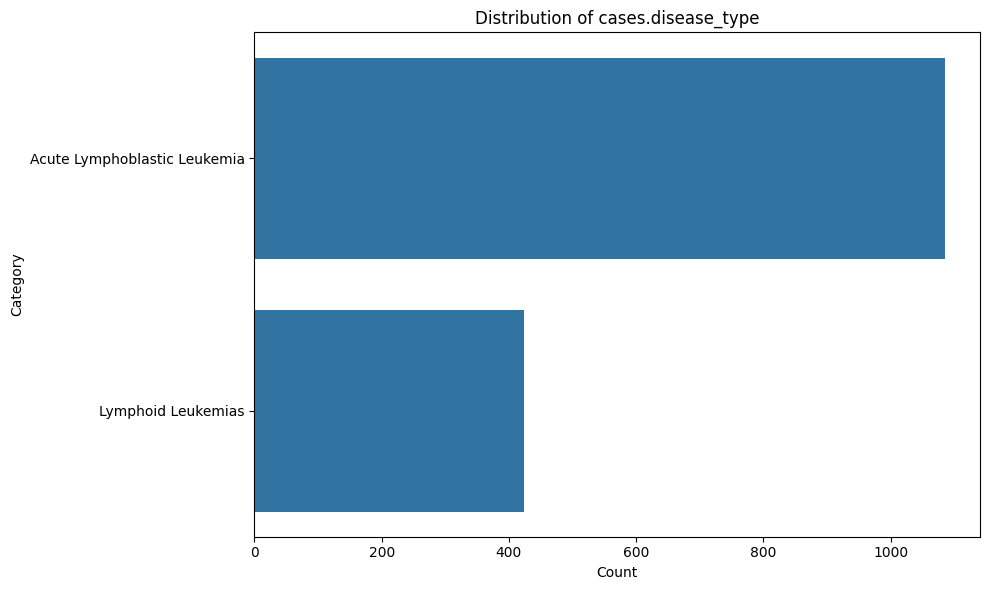

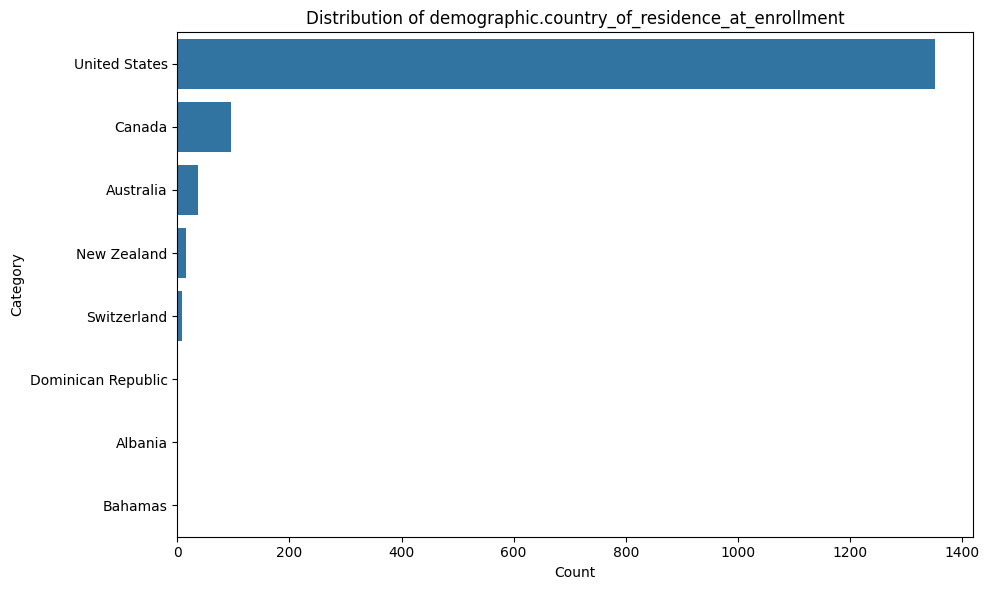


Column 'demographic.days_to_death' has 133 unique values (exceeds threshold 30). Printing value counts instead of plotting:
demographic.days_to_death
1165    2
611     2
1002    2
1620    1
1270    1
       ..
927     1
1817    1
994     1
2640    1
1341    1
Name: count, Length: 133, dtype: int64


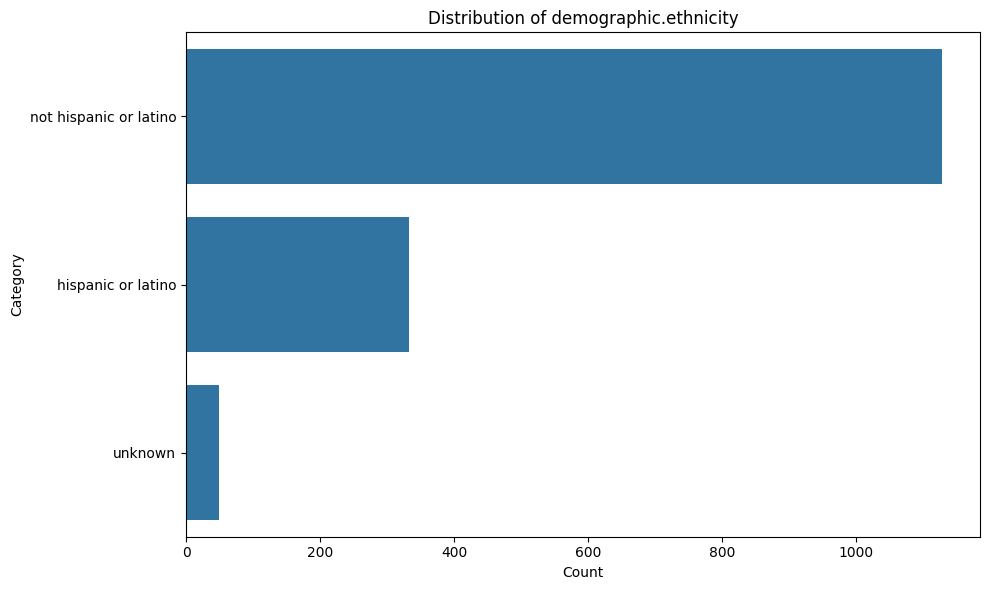

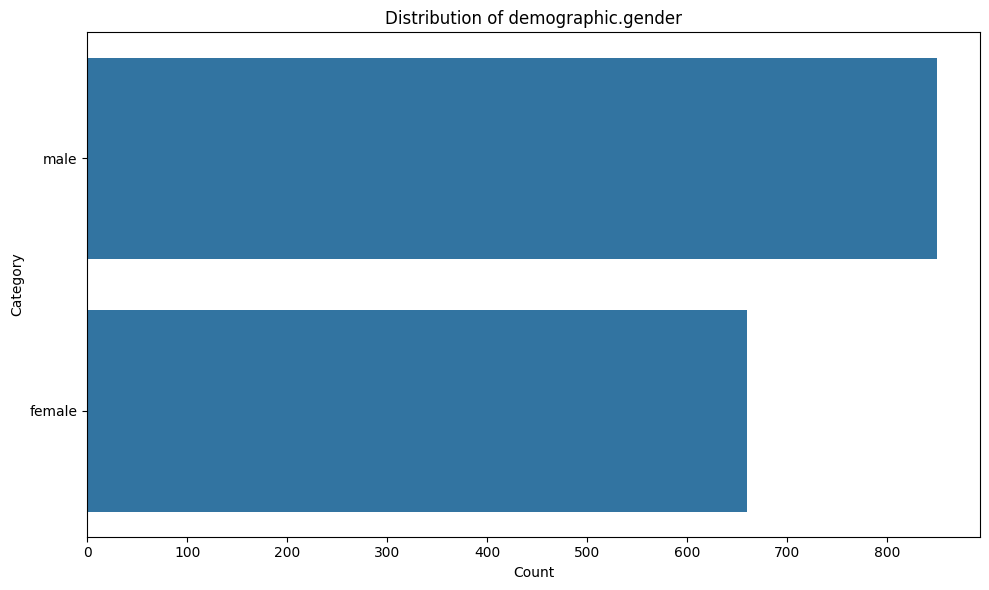

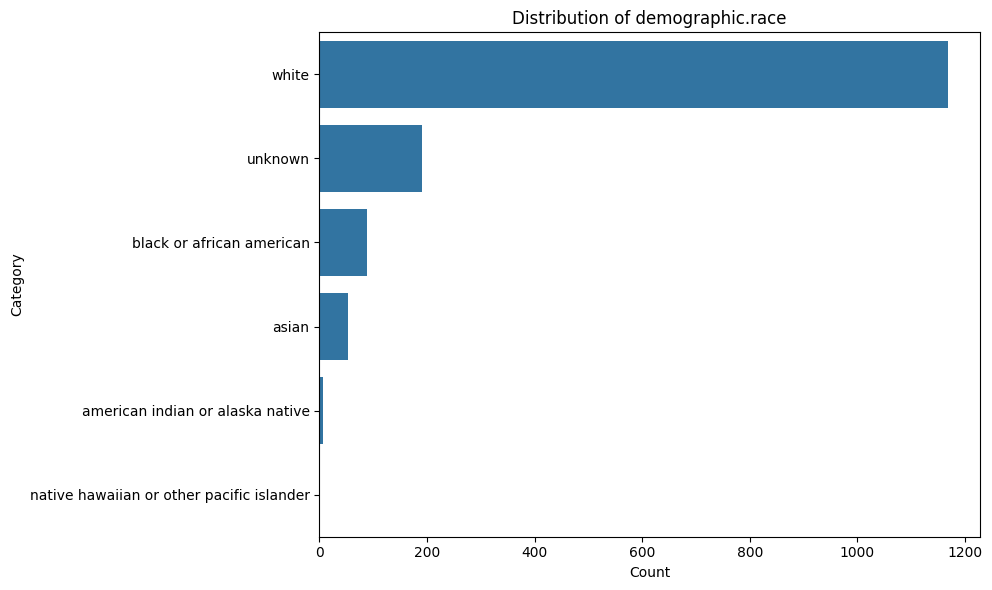

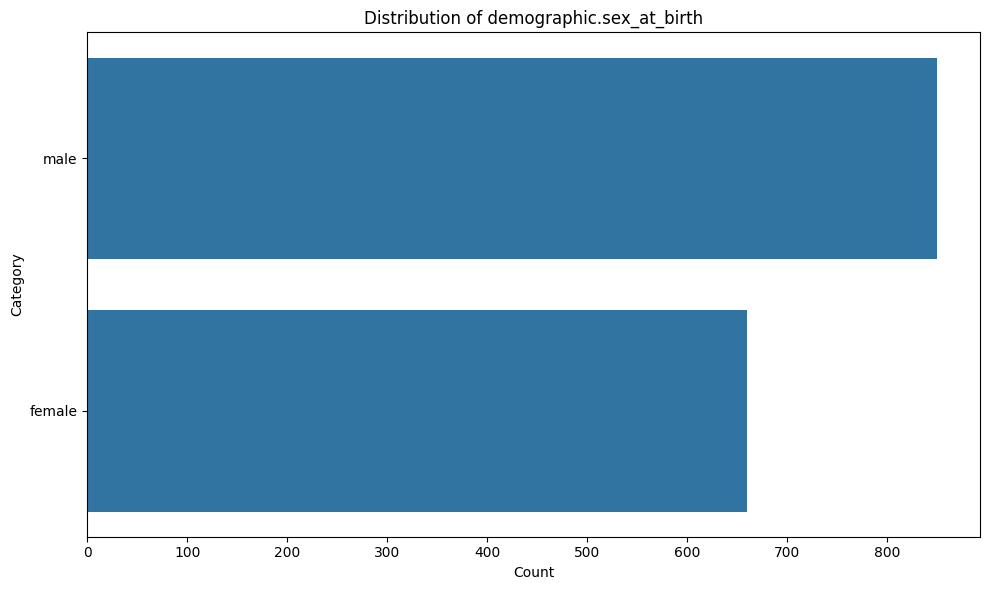

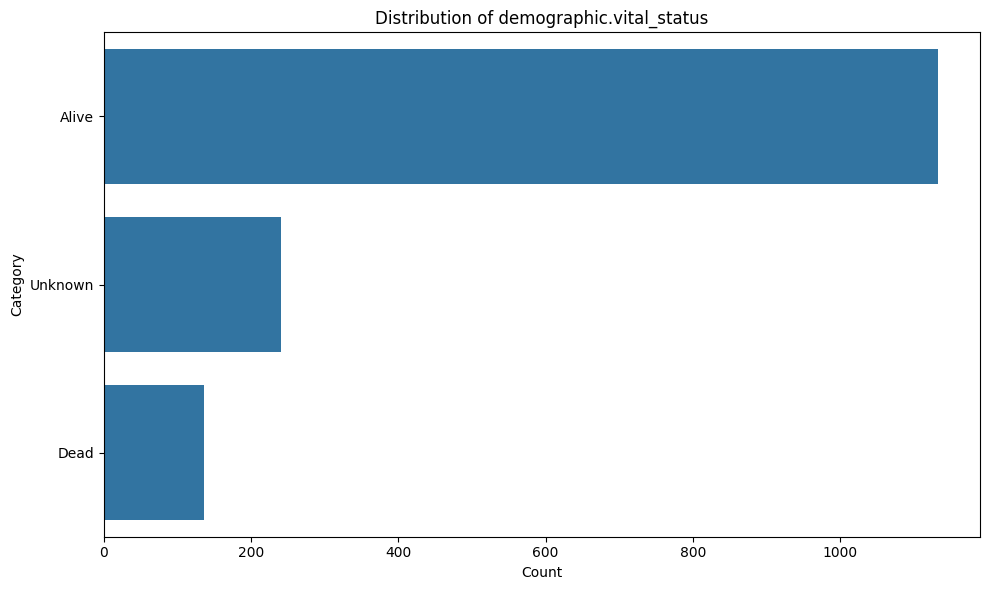

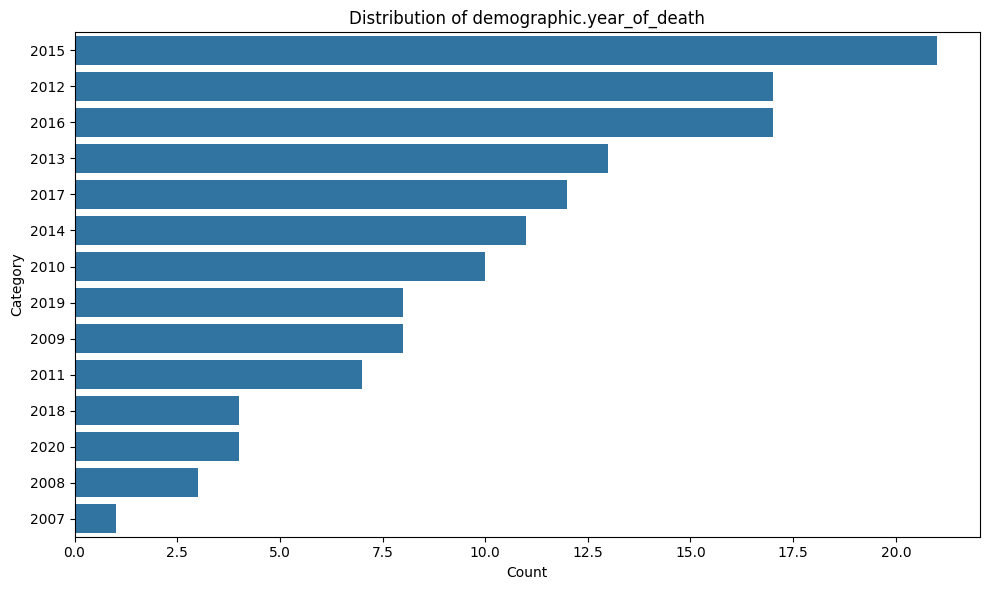

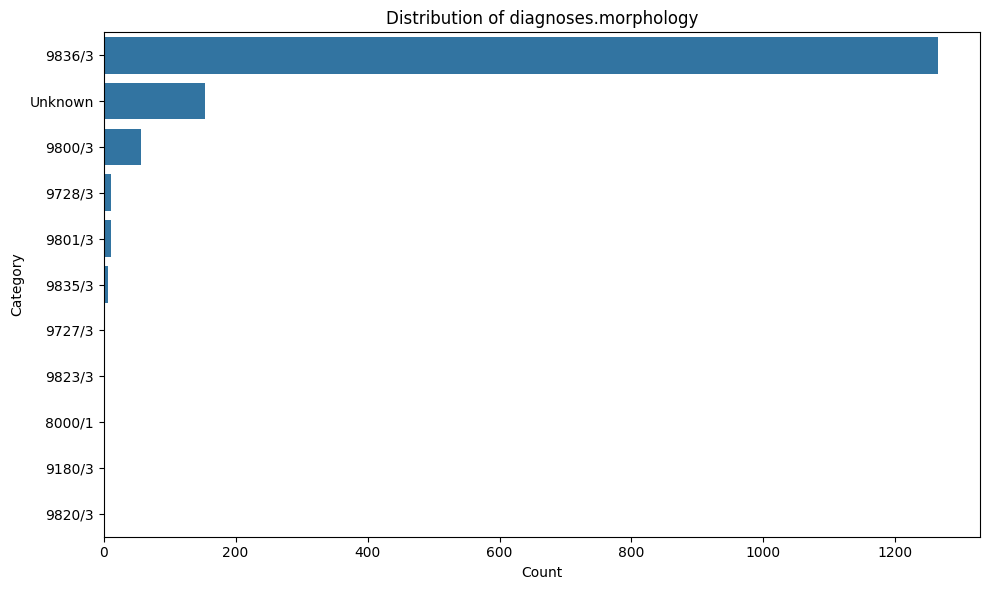

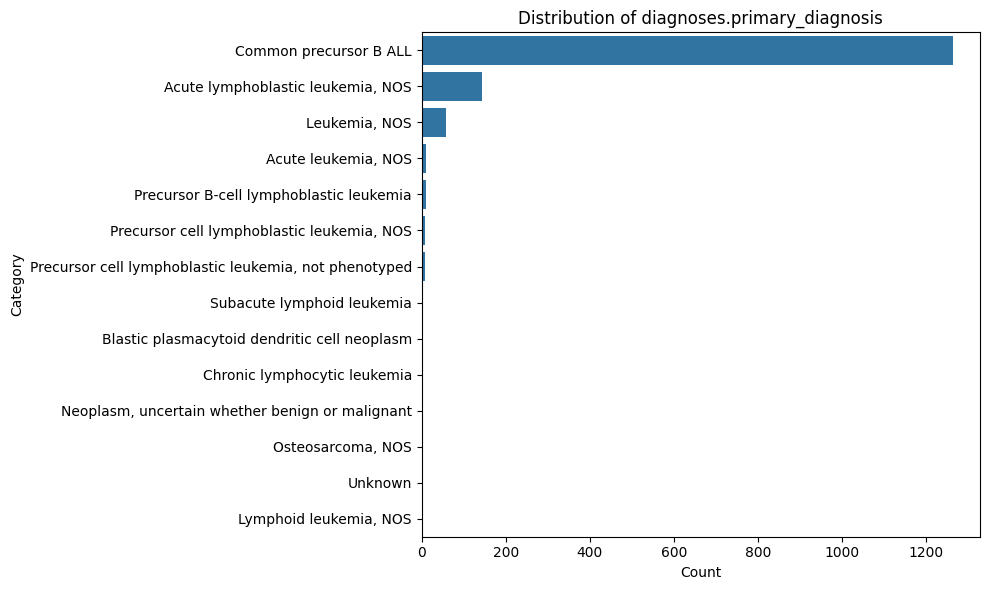

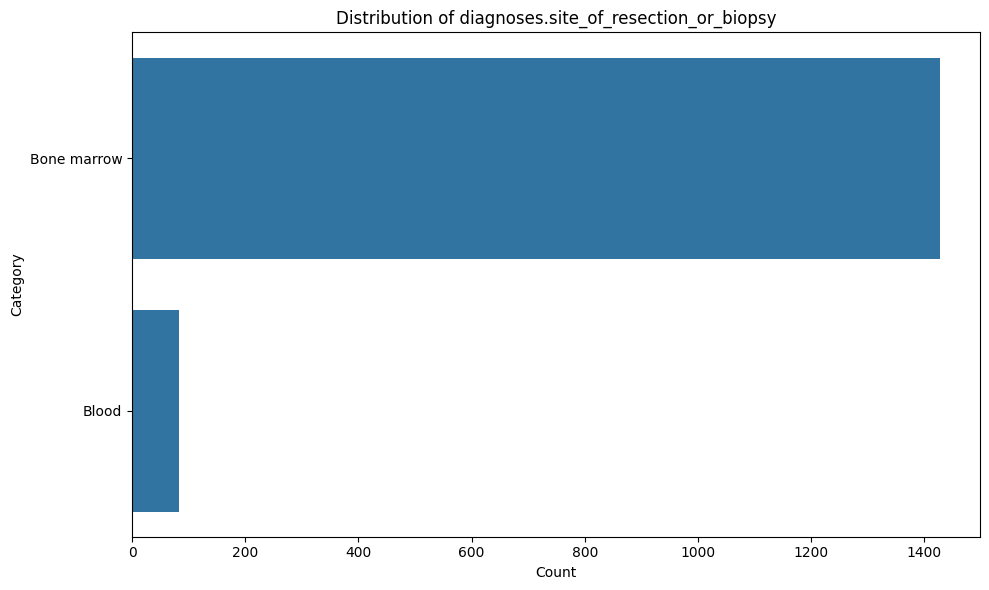

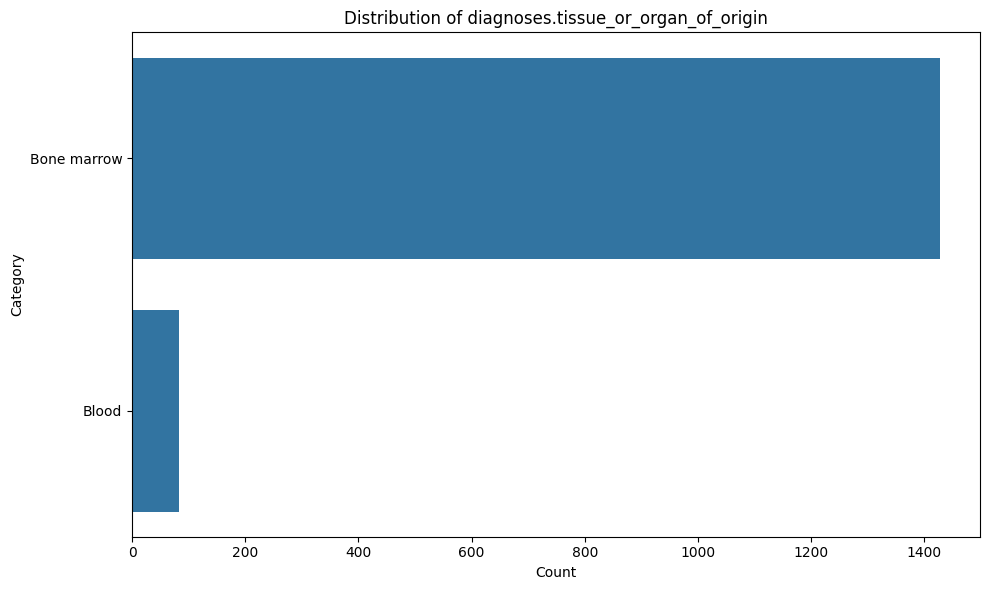

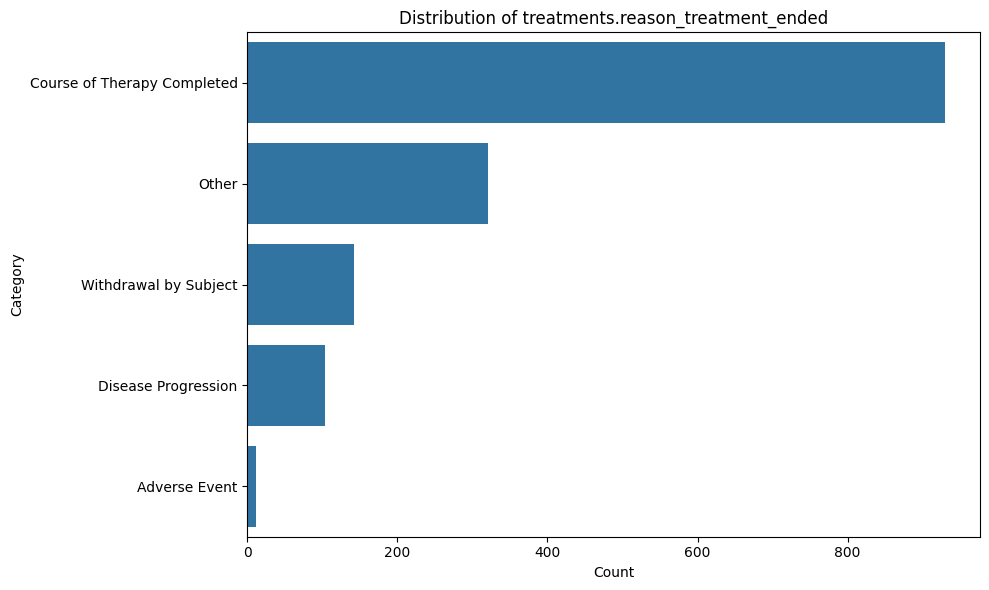


Column 'treatments.regimen_or_line_of_therapy' has 34 unique values (exceeds threshold 30). Printing value counts instead of plotting:
treatments.regimen_or_line_of_therapy
B-ALL Non-Down Syndrome  Induction Therapy                                                              176
Standard Induction - all patients in all groups                                                         138
SR-Low Group - LRS arm:  Standard Consolidation, Standard Interim Maintenance, Standard Delayed Inte     90
B-ALL Average Risk - Arm B Maintenance Therapy                                                           76
B-ALL Average Risk Post-Induction/Pre-Maintenance Therapy                                                74
SR-High Group - High arm:  Intensified Consolidation, Augmented Interim Maintenance, Augmented Delay     70
B-ALL Average Risk - Arm A Maintenance Therapy                                                           64
SR-Low Group - LRAsp-IV arm: SC+PEG; SIM+IV-MTX+PEG; SDI; Maintenance 

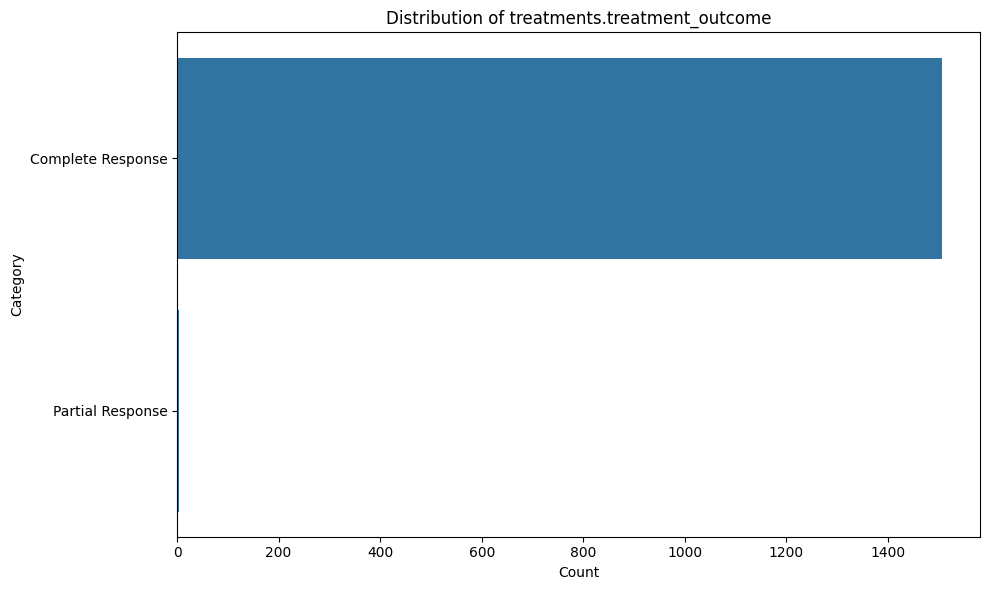

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns

# Exclude 'cases.case_id'
columns_to_plot = [col for col in df.select_dtypes(include='object').columns if col != 'cases.case_id']

# Set a threshold for the number of unique values to plot
# Columns with more than this threshold will have their value counts printed instead of a bar plot
UNIQUE_VALUE_THRESHOLD = 30

print("Generating category distribution plots and counts:")
for col in columns_to_plot:
    if df[col].nunique() <= UNIQUE_VALUE_THRESHOLD:
        plt.figure(figsize=(10, 6))
        sns.countplot(y=col, data=df, order=df[col].value_counts().index)
        plt.title(f'Distribution of {col}')
        plt.xlabel('Count')
        plt.ylabel('Category')
        plt.tight_layout()
        plt.show()
    else:
        print(f"\nColumn '{col}' has {df[col].nunique()} unique values (exceeds threshold {UNIQUE_VALUE_THRESHOLD}). Printing value counts instead of plotting:")
        print(df[col].value_counts())

In [14]:
df['demographic.days_to_death'] = pd.to_numeric(df['demographic.days_to_death'], errors='coerce')

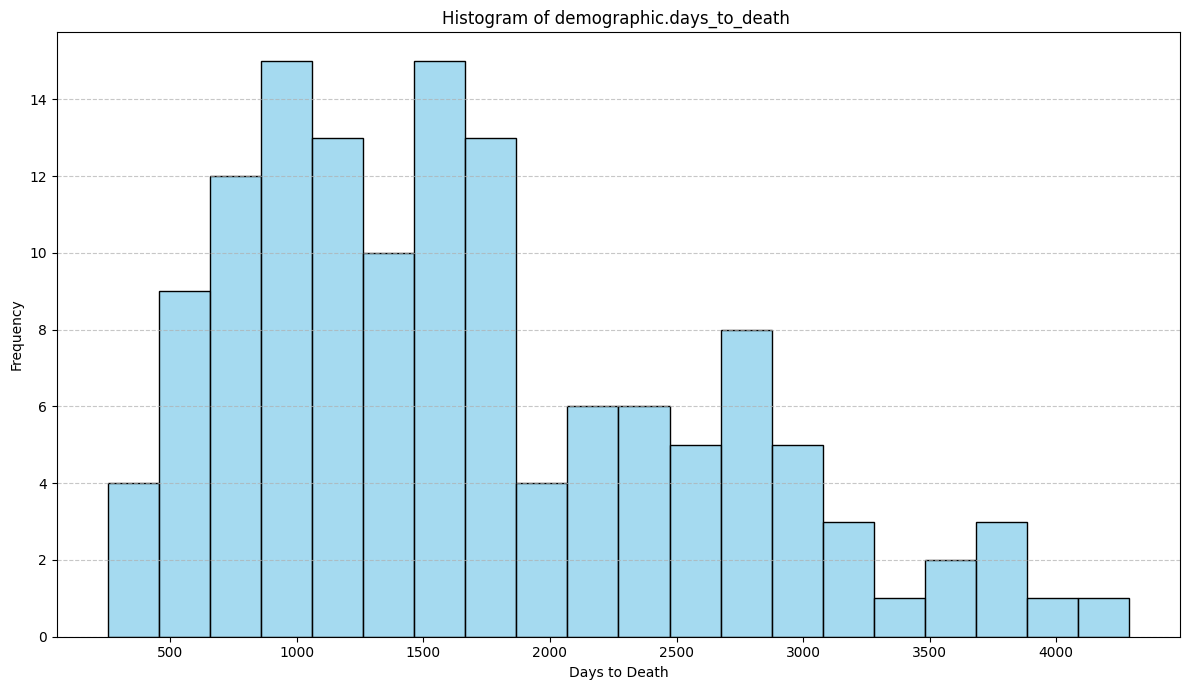

In [15]:
# Create bins and plot a histogram of days_to_death

fig = plt.figure(figsize=(12, 7))
sns.histplot(df['demographic.days_to_death'].dropna(), bins=20, kde=False, color='skyblue', edgecolor='black')
plt.title('Histogram of demographic.days_to_death ')
plt.xlabel('Days to Death')
plt.ylabel('Frequency')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

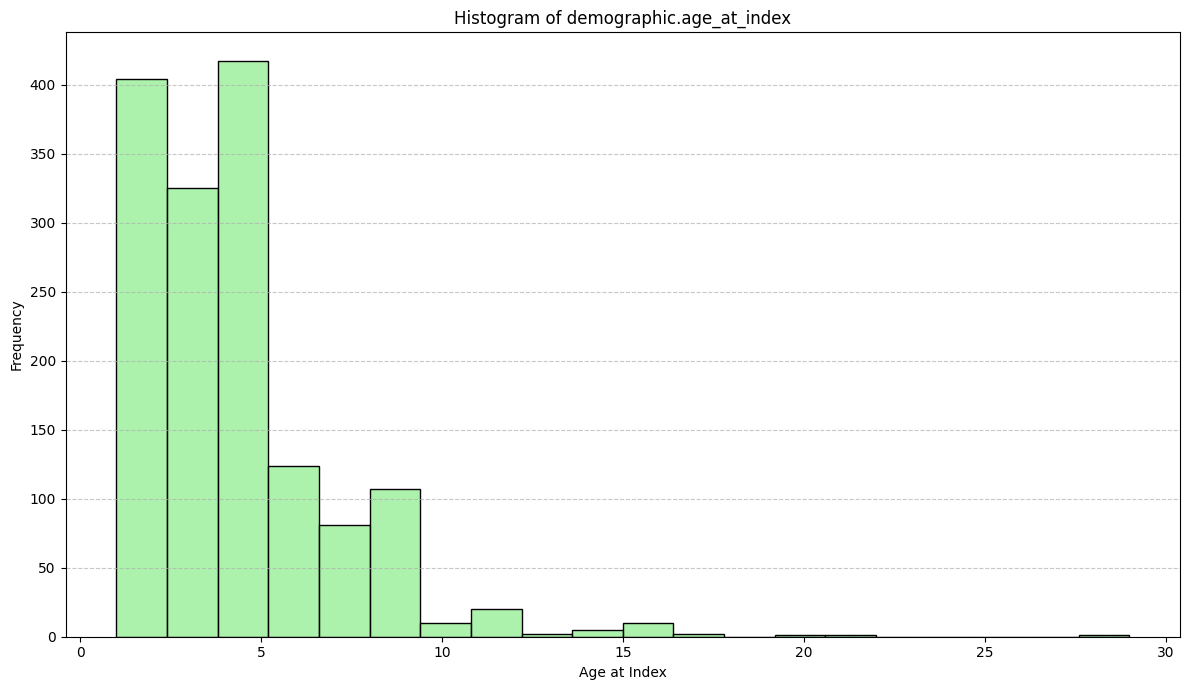

In [18]:
# Create an age plot histogram to observe distribution of age of patients
fig_age = plt.figure(figsize=(12, 7))
sns.histplot(df['demographic.age_at_index'].dropna(), bins=20, kde=False, color='lightgreen', edgecolor='black')
plt.title('Histogram of demographic.age_at_index')
plt.xlabel('Age at Index')
plt.ylabel('Frequency')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()